In [4]:
import os
import glob
import random
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from scipy import ndimage as ndi

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
class CFG:
    data_root = "./dsb2018_data"
    processed_root = "./dsb2018_processed"
    img_size = 256
    batch_size = 8
    num_workers = 2
    epochs = 30
    lr = 1e-4
    val_split = 0.15
    test_split = 0.10
    out_dir = "./outputs"
    checkpoint_path = "./outputs/unet_dsb2018.pth"
    report_path = "./outputs/report.md"

os.makedirs(CFG.out_dir, exist_ok=True)

In [6]:
import os
import zipfile
import urllib.request

CFG_data_root = "./dsb2018_data"
os.makedirs(CFG_data_root, exist_ok=True)

BBBC038_URL = "https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip"
zip_path = os.path.join(CFG_data_root, "stage1_train.zip")

if not os.path.exists(zip_path):
    print("Downloading stage1_train.zip (~83 MB) from the Broad Institute mirror...")
    urllib.request.urlretrieve(BBBC038_URL, zip_path)
    print("Download complete.")
else:
    print("Zip already present, skipping download.")

extract_dir = os.path.join(CFG_data_root, "stage1_train")
if not os.path.exists(extract_dir):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Extraction complete.")

stage1_train_dir = extract_dir
path = CFG_data_root  # kept for parity with the rest of the notebook
print("stage1_train dir:", stage1_train_dir)

Download complete.
Extracting...
Extraction complete.
stage1_train dir: ./dsb2018_data/stage1_train


In [7]:
def build_combined_masks(stage1_train_dir, processed_root=CFG.processed_root):
    """DSB2018 ships one binary mask PER nucleus. Combine them into a single
    semantic mask per image (union of all nuclei) and save image+mask pairs
    as flat PNGs for simple Dataset loading downstream."""
    img_out = Path(processed_root) / "images"
    mask_out = Path(processed_root) / "masks"
    img_out.mkdir(parents=True, exist_ok=True)
    mask_out.mkdir(parents=True, exist_ok=True)

    sample_dirs = sorted(glob.glob(os.path.join(stage1_train_dir, "*")))
    for sample_dir in tqdm(sample_dirs, desc="Combining masks"):
        sample_id = os.path.basename(sample_dir)
        img_path = glob.glob(os.path.join(sample_dir, "images", "*.png"))[0]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        mask_paths = glob.glob(os.path.join(sample_dir, "masks", "*.png"))
        combined = np.zeros(img.shape[:2], dtype=np.uint8)
        for mp in mask_paths:
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            combined[m > 0] = 255

        cv2.imwrite(str(img_out / f"{sample_id}.png"), img)
        cv2.imwrite(str(mask_out / f"{sample_id}.png"), combined)

    print(f"Saved {len(sample_dirs)} image/mask pairs to {processed_root}")
    return str(img_out), str(mask_out)

img_dir, mask_dir = build_combined_masks(stage1_train_dir)

Combining masks: 100%|██████████| 670/670 [00:30<00:00, 21.95it/s]

Saved 670 image/mask pairs to ./dsb2018_processed


EDA scan: 100%|██████████| 670/670 [00:06<00:00, 109.77it/s]


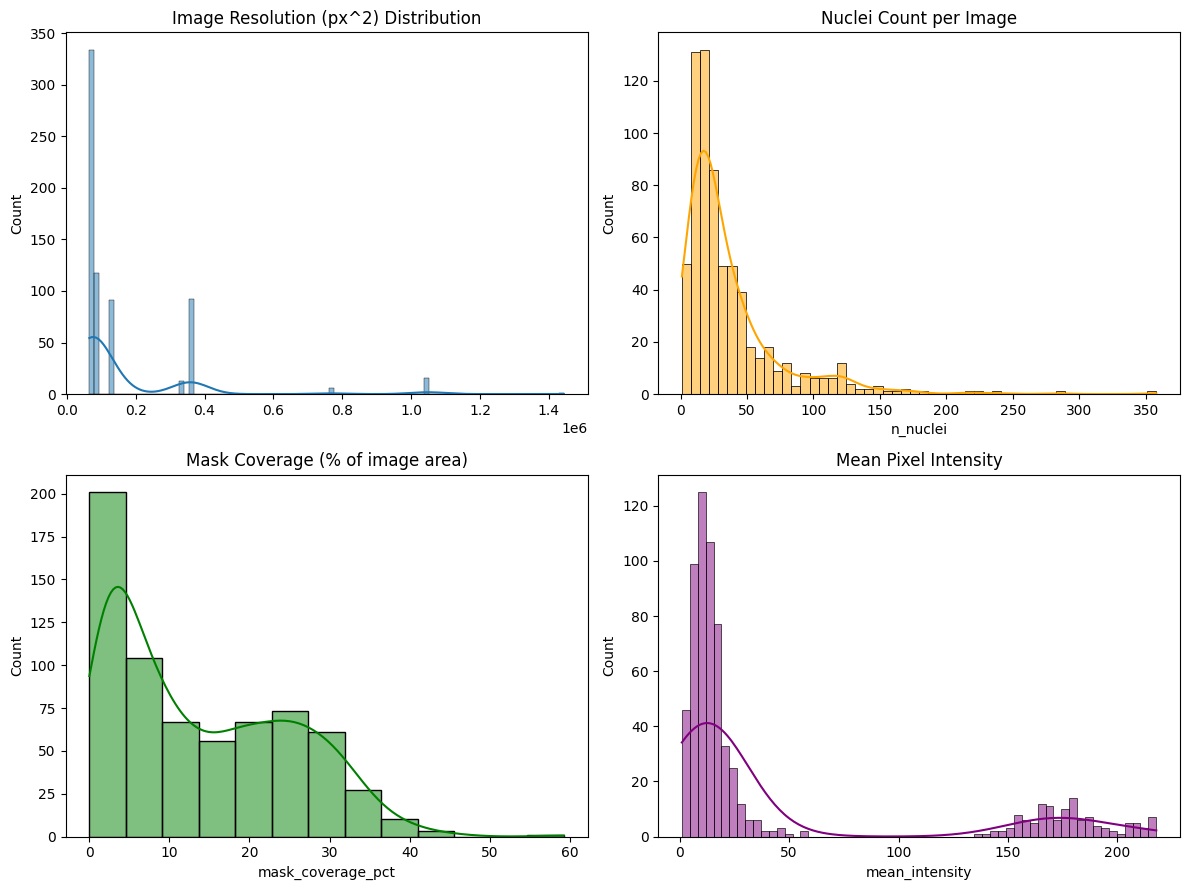

            height        width  channels  mean_intensity  mask_coverage_pct  \
count   670.000000   670.000000     670.0      670.000000         670.000000   
mean    333.991045   378.500000       3.0       43.772682          13.919112   
std     149.474845   204.838693       0.0       64.793887          11.072258   
min     256.000000   256.000000       3.0        0.983032           0.028818   
25%     256.000000   256.000000       3.0        8.951352           3.405762   
50%     256.000000   320.000000       3.0       13.781982          10.672760   
75%     360.000000   360.000000       3.0       24.782345          23.374023   
max    1040.000000  1388.000000       3.0      217.767636          59.202881   

         n_nuclei  
count  670.000000  
mean    36.247761  
std     37.907977  
min      1.000000  
25%     13.250000  
50%     23.000000  
75%     43.750000  
max    358.000000  


In [8]:
def run_eda(processed_root=CFG.processed_root, out_dir=CFG.out_dir):
    img_files = sorted(glob.glob(os.path.join(processed_root, "images", "*.png")))
    mask_files = sorted(glob.glob(os.path.join(processed_root, "masks", "*.png")))
    assert len(img_files) == len(mask_files), "Image/mask count mismatch"

    records = []
    for ip, mp in tqdm(list(zip(img_files, mask_files)), desc="EDA scan"):
        img = cv2.imread(ip)
        mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        n_nuclei = label(mask > 0).max()
        records.append({
            "id": os.path.basename(ip),
            "height": img.shape[0],
            "width": img.shape[1],
            "channels": img.shape[2],
            "mean_intensity": img.mean(),
            "mask_coverage_pct": 100 * (mask > 0).sum() / mask.size,
            "n_nuclei": n_nuclei,
        })

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(out_dir, "eda_summary.csv"), index=False)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    sns.histplot(df["width"] * df["height"], ax=axes[0, 0], kde=True)
    axes[0, 0].set_title("Image Resolution (px^2) Distribution")

    sns.histplot(df["n_nuclei"], ax=axes[0, 1], kde=True, color="orange")
    axes[0, 1].set_title("Nuclei Count per Image")

    sns.histplot(df["mask_coverage_pct"], ax=axes[1, 0], kde=True, color="green")
    axes[1, 0].set_title("Mask Coverage (% of image area)")

    sns.histplot(df["mean_intensity"], ax=axes[1, 1], kde=True, color="purple")
    axes[1, 1].set_title("Mean Pixel Intensity")

    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "eda_plots.png"), dpi=150)
    plt.show()

    print(df.describe())
    return df

eda_df = run_eda()

In [9]:
def preprocess_image(img_bgr, img_size=CFG.img_size, clahe=True, denoise=True):
    """Resize, denoise, contrast-enhance, normalize."""
    img = cv2.resize(img_bgr, (img_size, img_size), interpolation=cv2.INTER_AREA)

    if denoise:
        img = cv2.fastNlMeansDenoisingColored(img, None, 5, 5, 7, 21)

    if clahe:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe_op = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe_op.apply(l)
        img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

    img = img.astype(np.float32) / 255.0
    return img


def preprocess_mask(mask_gray, img_size=CFG.img_size):
    mask = cv2.resize(mask_gray, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    return mask

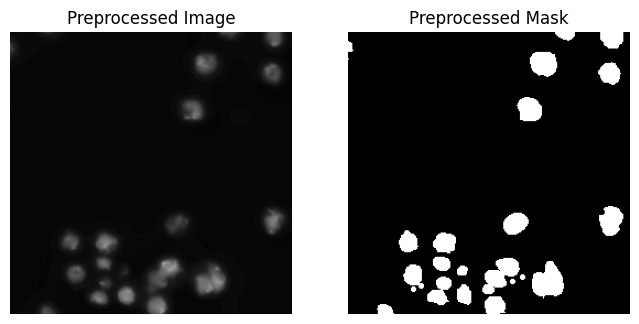

In [10]:
# Quick sanity check on one sample
sample_img_path = sorted(glob.glob(os.path.join(CFG.processed_root, "images", "*.png")))[0]
sample_mask_path = sorted(glob.glob(os.path.join(CFG.processed_root, "masks", "*.png")))[0]

raw_img = cv2.imread(sample_img_path)
raw_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

proc_img = preprocess_image(raw_img)
proc_mask = preprocess_mask(raw_mask)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.cvtColor((proc_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0].set_title("Preprocessed Image")
axes[1].imshow(proc_mask, cmap="gray")
axes[1].set_title("Preprocessed Mask")
for ax in axes: ax.axis("off")
plt.show()

In [11]:
class Augmenter:
    """Lightweight joint image+mask augmentation. Swap for `albumentations`
    if you want a richer pipeline — this keeps dependencies minimal."""

    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img, mask):
        if random.random() < self.p:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() < self.p:
            img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        if random.random() < self.p:
            k = random.choice([1, 2, 3])
            img = np.rot90(img, k).copy()
            mask = np.rot90(mask, k).copy()
        if random.random() < self.p:
            angle = random.uniform(-20, 20)
            h, w = mask.shape[:2]
            M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
            mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        if random.random() < self.p:
            factor = random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 1)
        if random.random() < self.p * 0.5:
            noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 1)
        return img, mask

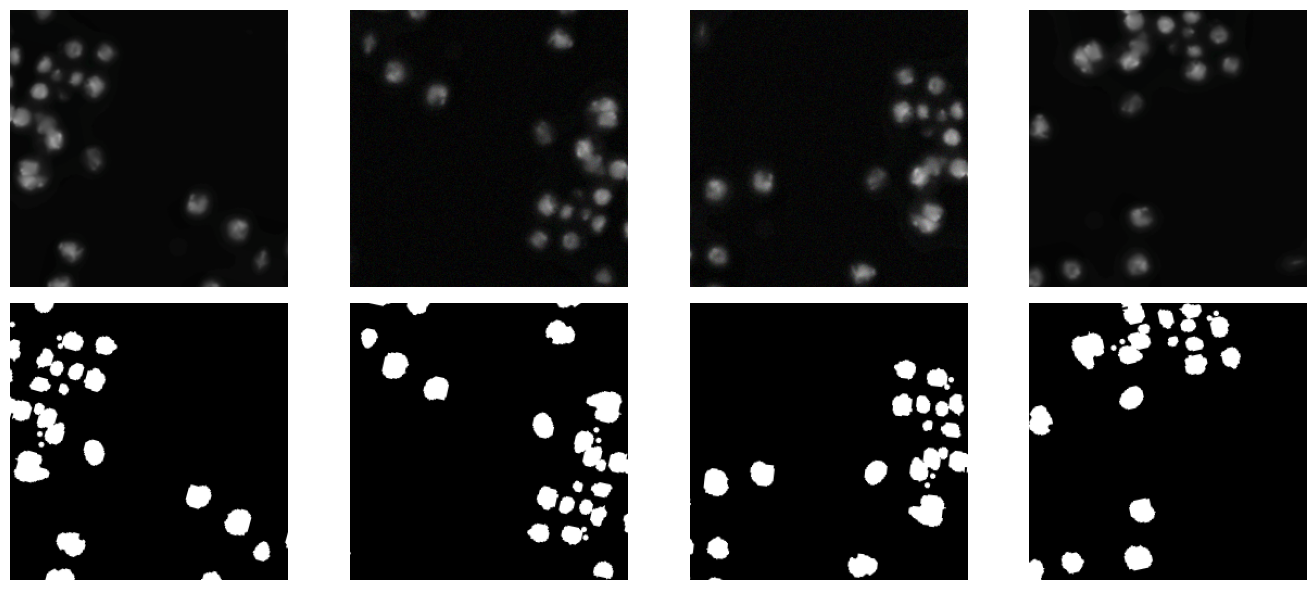

In [12]:
# Visualize a few augmented samples
aug = Augmenter(p=0.8)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    a_img, a_mask = aug(proc_img.copy(), proc_mask.copy())
    axes[0, i].imshow(cv2.cvtColor((a_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)); axes[0, i].axis("off")
    axes[1, i].imshow(a_mask, cmap="gray"); axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [13]:
class NucleiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=CFG.img_size, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.augmenter = Augmenter(p=0.5) if augment else None

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = preprocess_image(img, self.img_size)
        mask = preprocess_mask(mask, self.img_size)

        if self.augmenter:
            img, mask = self.augmenter(img, mask)

        img = torch.from_numpy(img.transpose(2, 0, 1)).float()   # C,H,W
        mask = torch.from_numpy(mask).unsqueeze(0).float()        # 1,H,W
        return img, mask

In [14]:
def get_dataloaders(processed_root=CFG.processed_root, cfg=CFG):
    img_files = sorted(glob.glob(os.path.join(processed_root, "images", "*.png")))
    mask_files = sorted(glob.glob(os.path.join(processed_root, "masks", "*.png")))

    train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
        img_files, mask_files, test_size=cfg.val_split + cfg.test_split, random_state=SEED
    )
    rel_test = cfg.test_split / (cfg.val_split + cfg.test_split)
    val_imgs, test_imgs, val_masks, test_masks = train_test_split(
        temp_imgs, temp_masks, test_size=rel_test, random_state=SEED
    )

    train_ds = NucleiDataset(train_imgs, train_masks, cfg.img_size, augment=True)
    val_ds = NucleiDataset(val_imgs, val_masks, cfg.img_size, augment=False)
    test_ds = NucleiDataset(test_imgs, test_masks, cfg.img_size, augment=False)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                               num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                             num_workers=cfg.num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader, (test_imgs, test_masks)

train_loader, val_loader, test_loader, (test_imgs, test_masks) = get_dataloaders()

Train: 502 | Val: 100 | Test: 68


In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        c = in_channels
        for f in features:
            self.downs.append(DoubleConv(c, f))
            c = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[i + 1](x)

        return self.final_conv(x)  # raw logits

In [16]:
# Sanity check forward pass
_test_model = UNet().to(DEVICE)
_test_input = torch.randn(2, 3, CFG.img_size, CFG.img_size).to(DEVICE)
_test_out = _test_model(_test_input)
print("Output shape:", _test_out.shape)
del _test_model, _test_input, _test_out

Output shape: torch.Size([2, 1, 256, 256])


In [17]:
def dice_coeff(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2 * intersection + eps) / (union + eps)).mean().item()


def iou_score(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()


def precision_recall_f1(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fp = (pred * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - pred) * target).sum(dim=(1, 2, 3))
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return precision.mean().item(), recall.mean().item(), f1.mean().item()


class DiceBCELoss(nn.Module):
    def forward(self, pred, target, eps=1e-7):
        bce = F.binary_cross_entropy_with_logits(pred, target)
        pred_sig = torch.sigmoid(pred)
        intersection = (pred_sig * target).sum(dim=(1, 2, 3))
        union = pred_sig.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice_loss = 1 - ((2 * intersection + eps) / (union + eps)).mean()
        return bce + dice_loss

In [18]:
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss = tot_dice = tot_iou = tot_p = tot_r = tot_f1 = 0.0
    n = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, masks)

            tot_loss += loss.item()
            tot_dice += dice_coeff(preds, masks)
            tot_iou += iou_score(preds, masks)
            p, r, f1 = precision_recall_f1(preds, masks)
            tot_p += p; tot_r += r; tot_f1 += f1
            n += 1

    return {
        "loss": tot_loss / n, "dice": tot_dice / n, "iou": tot_iou / n,
        "precision": tot_p / n, "recall": tot_r / n, "f1": tot_f1 / n,
    }

In [19]:
def save_model(model, path=CFG.checkpoint_path, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {"model_state_dict": model.state_dict()}
    if extra:
        payload.update(extra)
    torch.save(payload, path)


def plot_training_curves(history, out_dir=CFG.out_dir):
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df["epoch"], df["train_loss"], label="train_loss")
    axes[0].plot(df["epoch"], df["loss"], label="val_loss")
    axes[0].set_title("Loss"); axes[0].legend()

    for col in ["dice", "iou", "f1"]:
        axes[1].plot(df["epoch"], df[col], label=col)
    axes[1].set_title("Validation Metrics"); axes[1].legend()

    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "training_curves.png"), dpi=150)
    plt.show()


def train_model(train_loader, val_loader, cfg=CFG):
    model = UNet().to(DEVICE)
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    history = []
    best_dice = 0.0

    for epoch in range(cfg.epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
        for imgs, masks in pbar:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        val_metrics = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} "
              f"val_loss={val_metrics['loss']:.4f} dice={val_metrics['dice']:.4f} "
              f"iou={val_metrics['iou']:.4f} f1={val_metrics['f1']:.4f}")

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            save_model(model, cfg.checkpoint_path, extra={"epoch": epoch + 1, "val_dice": best_dice})

    pd.DataFrame(history).to_csv(os.path.join(cfg.out_dir, "training_history.csv"), index=False)
    plot_training_curves(history, cfg.out_dir)
    return model, history

Epoch 1/30: 100%|██████████| 63/63 [01:53<00:00,  1.80s/it, loss=0.939]


Epoch 1: train_loss=1.1139 val_loss=1.0313 dice=0.6992 iou=0.5719 f1=0.6992


Epoch 2/30: 100%|██████████| 63/63 [01:53<00:00,  1.80s/it, loss=0.695]


Epoch 2: train_loss=0.8877 val_loss=0.8451 dice=0.8046 iou=0.7082 f1=0.8046


Epoch 3/30: 100%|██████████| 63/63 [01:53<00:00,  1.80s/it, loss=0.871]


...

Epoch 28: train_loss=0.2805 val_loss=0.2300 dice=0.8926 iou=0.8165 f1=0.8926


Epoch 29/30: 100%|██████████| 63/63 [01:51<00:00,  1.76s/it, loss=0.256]


Epoch 29: train_loss=0.2645 val_loss=0.2262 dice=0.8957 iou=0.8197 f1=0.8957


Epoch 30/30: 100%|██████████| 63/63 [01:51<00:00,  1.78s/it, loss=0.26]


Epoch 30: train_loss=0.2599 val_loss=0.2187 dice=0.8930 iou=0.8186 f1=0.8930


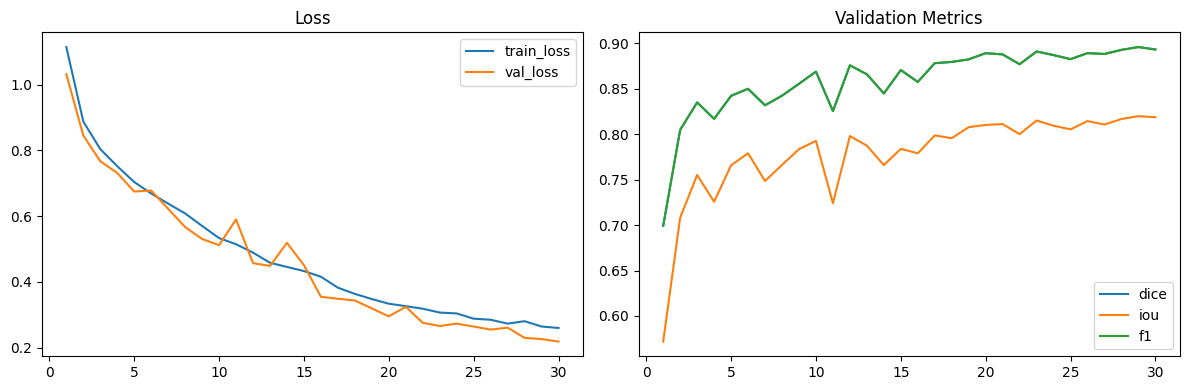

In [20]:
model, history = train_model(train_loader, val_loader)

In [21]:
def load_model(path=CFG.checkpoint_path):
    m = UNet().to(DEVICE)
    checkpoint = torch.load(path, map_location=DEVICE)
    m.load_state_dict(checkpoint["model_state_dict"])
    m.eval()
    return m

model = load_model()
test_metrics = evaluate(model, test_loader, DiceBCELoss())
print("Test metrics:", test_metrics)

Test metrics: {'loss': 0.1907088259855906, 'dice': 0.9189134438832601, 'iou': 0.8543123536639743, 'precision': 0.9375853141148885, 'recall': 0.9062106675571866, 'f1': 0.918913377655877}


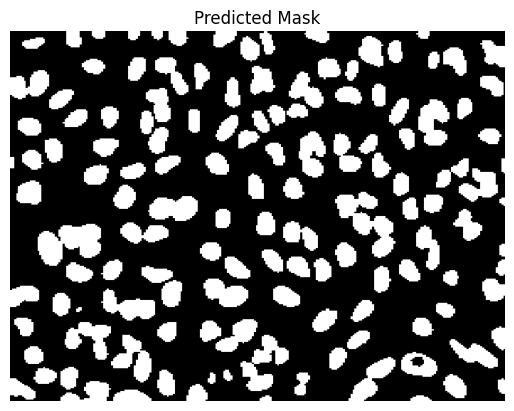

In [22]:
def predict_mask(model, img_bgr, img_size=CFG.img_size, threshold=0.5):
    orig_h, orig_w = img_bgr.shape[:2]
    img = preprocess_image(img_bgr, img_size)
    tensor = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()

    pred_mask = (prob > threshold).astype(np.uint8) * 255
    pred_mask = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return pred_mask

# Example on one test image
example_img = cv2.imread(test_imgs[0])
example_pred = predict_mask(model, example_img)
plt.imshow(example_pred, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

Detected cells: 148


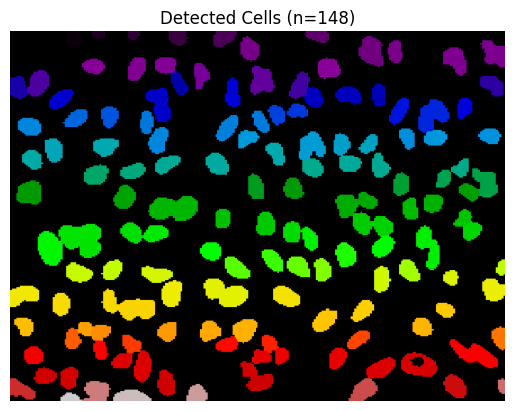

In [23]:
def detect_cells(binary_mask):
    """Split a semantic (binary) mask into individual nucleus instances."""
    mask_bool = binary_mask > 0
    distance = ndi.distance_transform_edt(mask_bool)
    coords_mask = distance > 0.5 * distance.max()
    markers = label(coords_mask)
    labels_img = watershed(-distance, markers, mask=mask_bool)
    n_cells = labels_img.max()
    return labels_img, n_cells

example_labels, example_n_cells = detect_cells(example_pred)
print("Detected cells:", example_n_cells)
plt.imshow(example_labels, cmap="nipy_spectral")
plt.title(f"Detected Cells (n={example_n_cells})")
plt.axis("off")
plt.show()

In [24]:
def extract_cell_features(labels_img, image_id=None):
    props = regionprops(labels_img)
    rows = []
    for p in props:
        rows.append({
            "image_id": image_id,
            "cell_id": p.label,
            "area": p.area,
            "perimeter": p.perimeter,
            "eccentricity": p.eccentricity,
            "solidity": p.solidity,
            "major_axis_length": p.major_axis_length,
            "minor_axis_length": p.minor_axis_length,
            "circularity": (4 * np.pi * p.area / (p.perimeter ** 2)) if p.perimeter > 0 else 0,
            "centroid_row": p.centroid[0],
            "centroid_col": p.centroid[1],
        })
    return pd.DataFrame(rows)

example_features = extract_cell_features(example_labels, image_id=os.path.basename(test_imgs[0]))
example_features.head()

,image_id,cell_id,area,perimeter,eccentricity,solidity,major_axis_length,minor_axis_length,circularity,centroid_row,centroid_col
0,175dbb364bfefc9537931144861c9b6e08934df3992782...,1,449.0,83.656854,0.510876,0.955319,26.100822,22.437687,0.806219,10.772829,89.015590
1,175dbb364bfefc9537931144861c9b6e08934df3992782...,2,189.0,54.242641,0.817120,0.974227,20.734149,11.952564,0.807216,4.566138,124.296296
2,175dbb364bfefc9537931144861c9b6e08934df3992782...,3,191.0,54.242641,0.664074,0.955000,18.426252,13.776696,0.815758,5.324607,173.434555
3,175dbb364bfefc9537931144861c9b6e08934df3992782...,4,467.0,89.485281,0.621934,0.928429,27.991030,21.918934,0.732864,8.897216,235.650964
4,175dbb364bfefc9537931144861c9b6e08934df3992782...,5,590.0,103.313708,0.797522,0.945513,36.139400,21.802520,0.694618,9.505085,300.072881


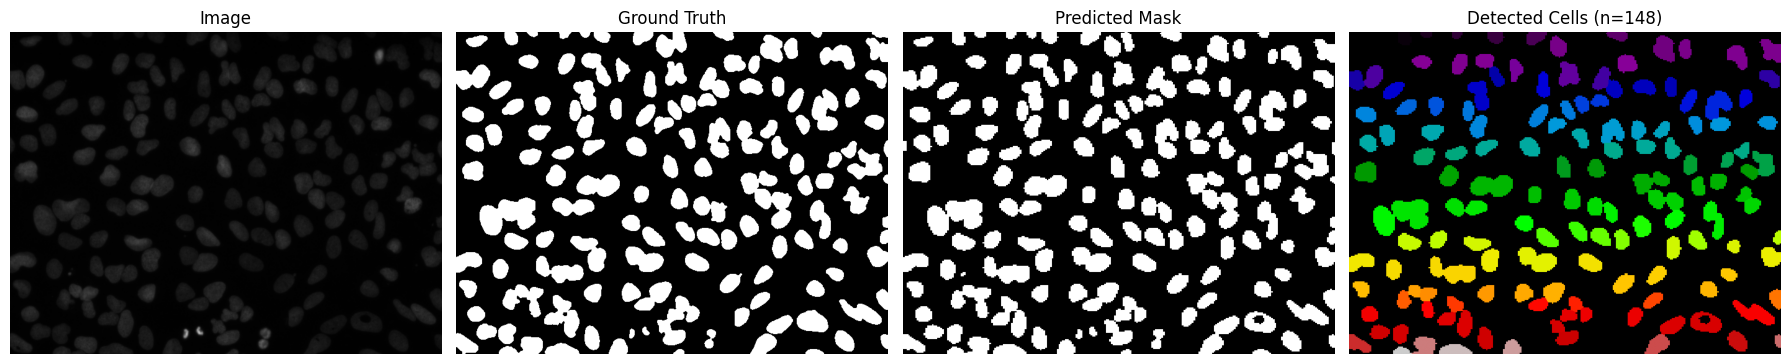

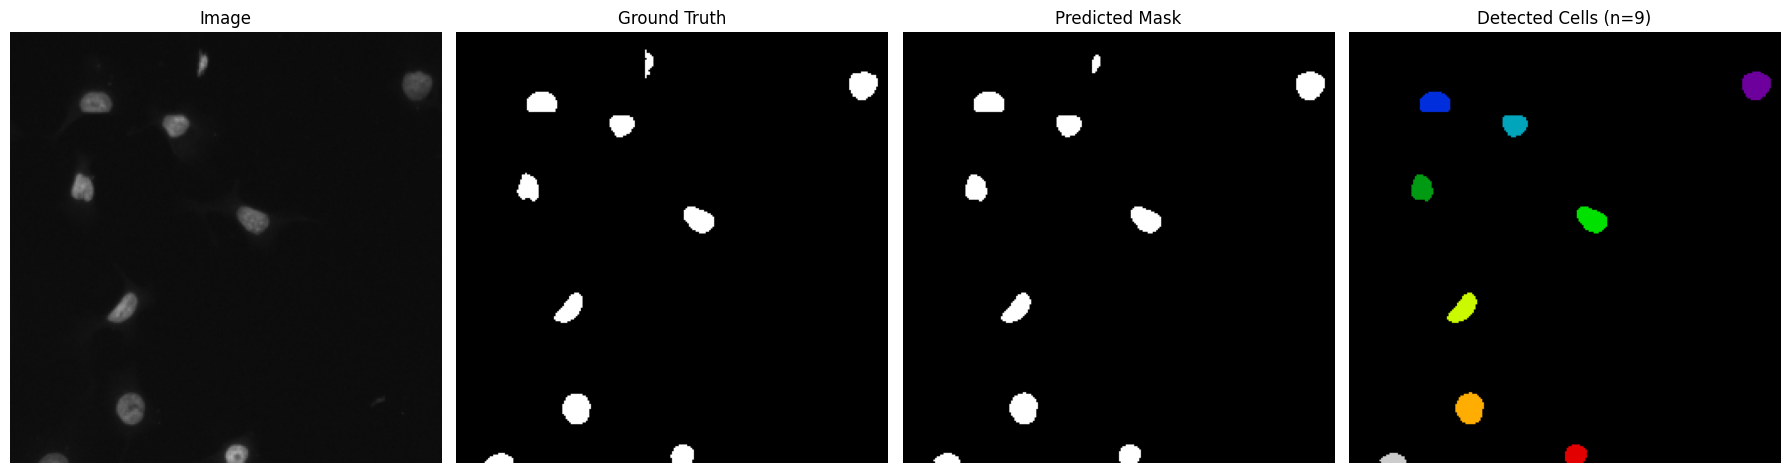

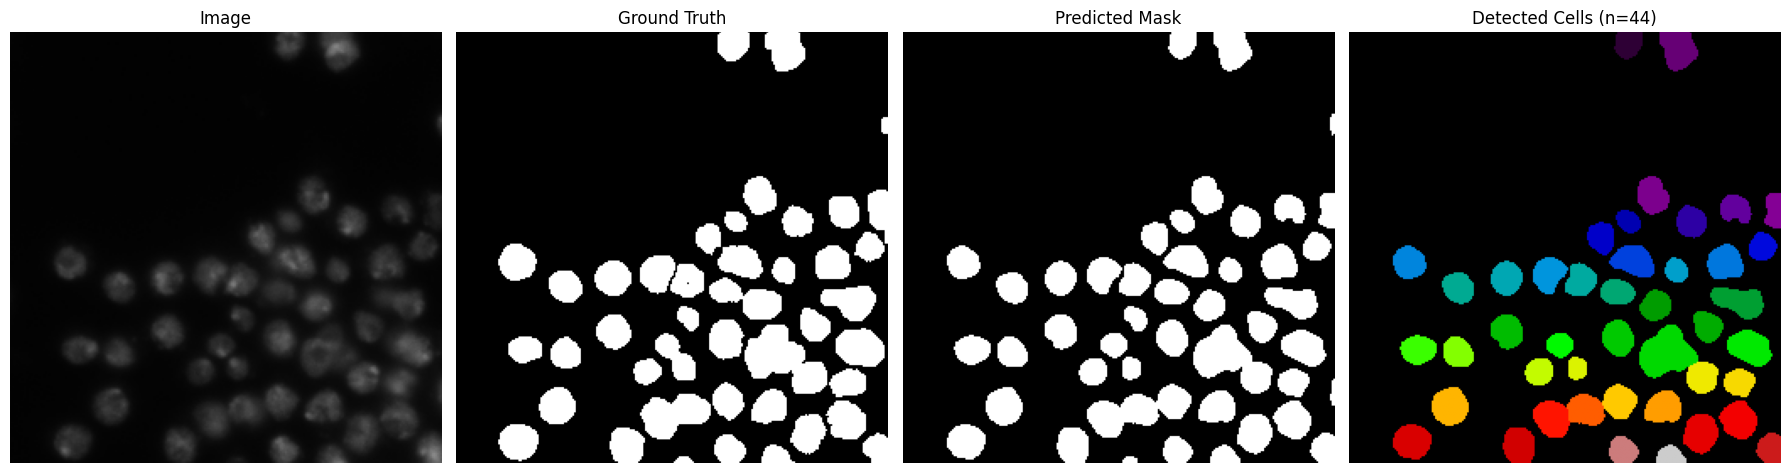

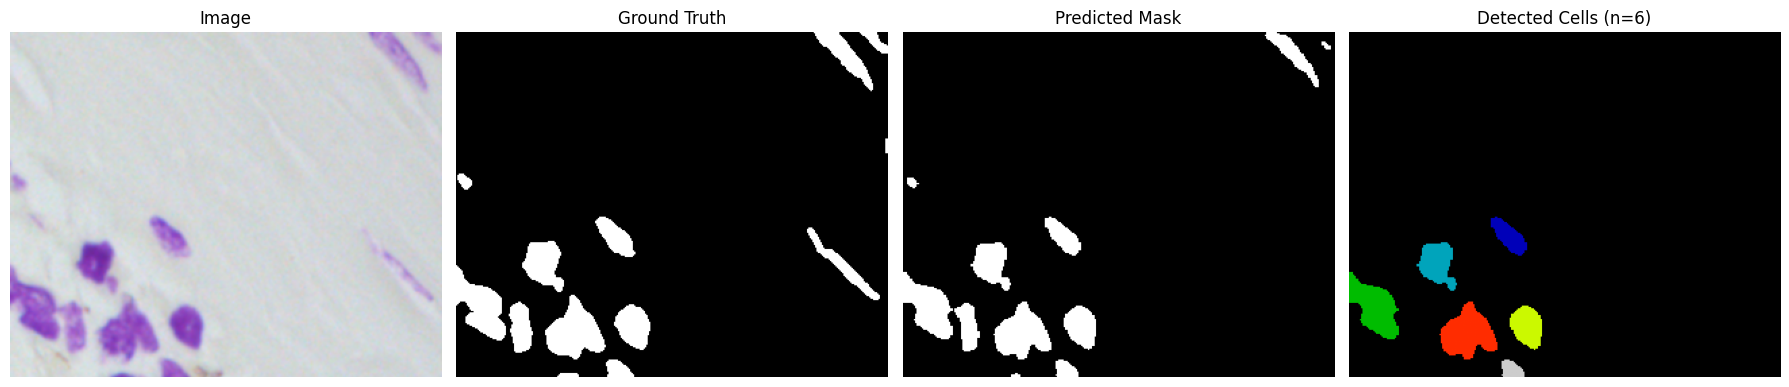

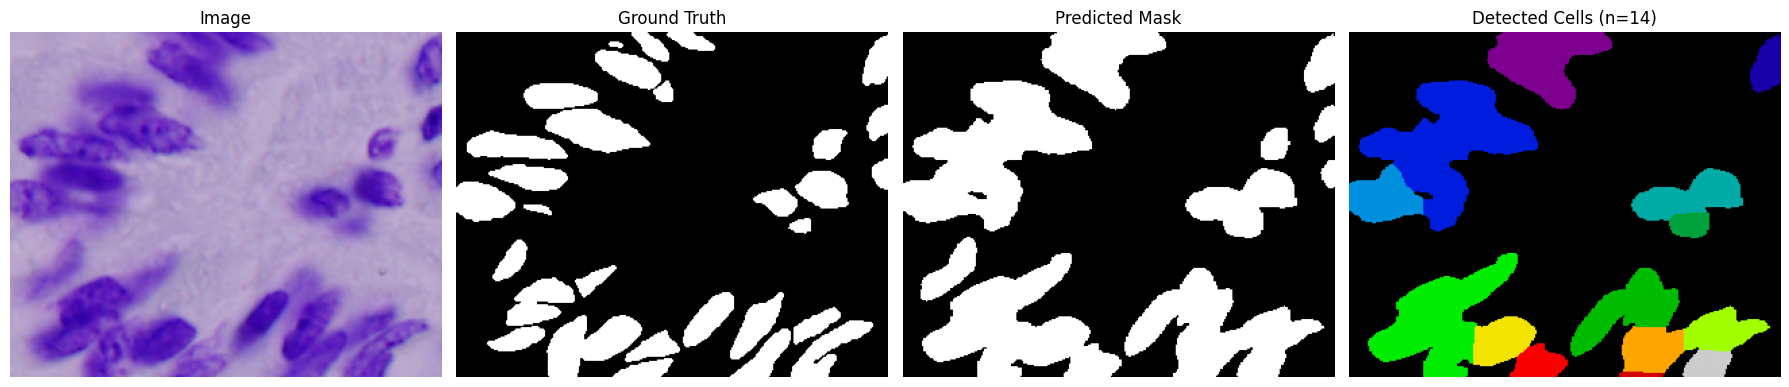

,image_id,cell_id,area,perimeter,eccentricity,solidity,major_axis_length,minor_axis_length,circularity,centroid_row,centroid_col
0,175dbb364bfefc9537931144861c9b6e08934df3992782...,1,449.0,83.656854,0.510876,0.955319,26.100822,22.437687,0.806219,10.772829,89.015590
1,175dbb364bfefc9537931144861c9b6e08934df3992782...,2,189.0,54.242641,0.817120,0.974227,20.734149,11.952564,0.807216,4.566138,124.296296
2,175dbb364bfefc9537931144861c9b6e08934df3992782...,3,191.0,54.242641,0.664074,0.955000,18.426252,13.776696,0.815758,5.324607,173.434555
3,175dbb364bfefc9537931144861c9b6e08934df3992782...,4,467.0,89.485281,0.621934,0.928429,27.991030,21.918934,0.732864,8.897216,235.650964
4,175dbb364bfefc9537931144861c9b6e08934df3992782...,5,590.0,103.313708,0.797522,0.945513,36.139400,21.802520,0.694618,9.505085,300.072881


In [25]:
# Run prediction + detection + feature extraction across the full test set
all_features = []
viz_count = 0

def visualize_prediction(img_bgr, gt_mask, pred_mask, labels_img, out_path):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Image")
    axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground Truth")
    axes[2].imshow(pred_mask, cmap="gray"); axes[2].set_title("Predicted Mask")
    axes[3].imshow(labels_img, cmap="nipy_spectral"); axes[3].set_title(f"Detected Cells (n={labels_img.max()})")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()

for i, (img_path, mask_path) in enumerate(zip(test_imgs, test_masks)):
    img_bgr = cv2.imread(img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    pred_mask = predict_mask(model, img_bgr)
    labels_img, n_cells = detect_cells(pred_mask)
    feats = extract_cell_features(labels_img, image_id=os.path.basename(img_path))
    all_features.append(feats)

    if viz_count < 5:
        visualize_prediction(img_bgr, gt_mask, pred_mask, labels_img,
                              os.path.join(CFG.out_dir, f"viz_{i}.png"))
        viz_count += 1

features_df = pd.concat(all_features, ignore_index=True)
features_df.to_csv(os.path.join(CFG.out_dir, "cell_features.csv"), index=False)
features_df.head()

In [26]:
def statistical_analysis(features_df, out_dir=CFG.out_dir):
    summary = features_df[["area", "perimeter", "eccentricity", "solidity",
                            "major_axis_length", "minor_axis_length", "circularity"]].describe()
    summary.to_csv(os.path.join(out_dir, "cell_feature_stats.csv"))

    per_image = features_df.groupby("image_id").agg(
        n_cells=("cell_id", "count"),
        mean_area=("area", "mean"),
        mean_circularity=("circularity", "mean"),
    ).reset_index()
    per_image.to_csv(os.path.join(out_dir, "per_image_summary.csv"), index=False)

    print(summary)
    return summary, per_image

feature_summary, per_image_summary = statistical_analysis(features_df)

               area    perimeter  eccentricity     solidity  \
count   1691.000000  1691.000000   1691.000000  1691.000000   
mean     663.706682    97.006696      0.694008     0.933610   
std      835.728126    68.290652      0.156447     0.043212   
min       17.000000    14.828427      0.053443     0.488363   
25%      181.000000    50.748737      0.600950     0.921562   
50%      455.000000    87.899495      0.716491     0.943396   
75%      777.500000   121.426407      0.807050     0.958739   
max    16562.000000  1305.705627      0.995506     1.000000   

       major_axis_length  minor_axis_length  circularity  
count        1691.000000        1691.000000  1691.000000  
mean           32.942830          21.288573     0.783709  
std            23.514012          11.115250     0.163617  
min             6.945774           2.423177     0.122077  
25%            18.581787          12.369835     0.682461  
50%            28.807886          20.144468     0.753382  
75%            41.1

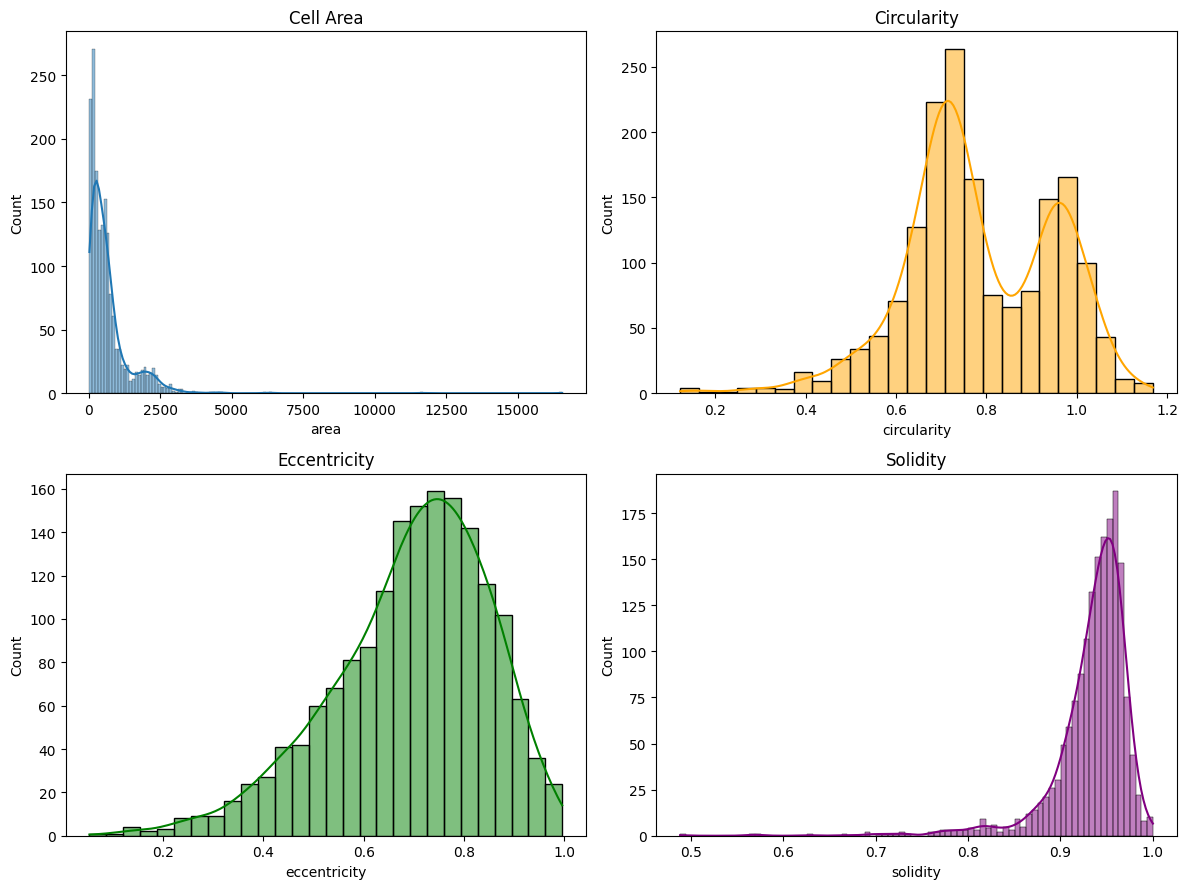

In [27]:
def visualize_feature_distributions(features_df, out_dir=CFG.out_dir):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    sns.histplot(features_df["area"], ax=axes[0, 0], kde=True); axes[0, 0].set_title("Cell Area")
    sns.histplot(features_df["circularity"], ax=axes[0, 1], kde=True, color="orange"); axes[0, 1].set_title("Circularity")
    sns.histplot(features_df["eccentricity"], ax=axes[1, 0], kde=True, color="green"); axes[1, 0].set_title("Eccentricity")
    sns.histplot(features_df["solidity"], ax=axes[1, 1], kde=True, color="purple"); axes[1, 1].set_title("Solidity")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, "feature_distributions.png"), dpi=150)
    plt.show()

visualize_feature_distributions(features_df)

In [28]:
# model = load_model(CFG.checkpoint_path)   # uncomment to reload later
print("Checkpoint saved at:", CFG.checkpoint_path)

Checkpoint saved at: ./outputs/unet_dsb2018.pth


In [29]:
def generate_report(test_metrics, feature_summary, per_image_summary, cfg=CFG):
    lines = [
        "# Nuclei Segmentation — DSB2018 Pipeline Report",
        f"_Generated: {datetime.now().isoformat(timespec='seconds')}_",
        "",
        "## Test Set Metrics",
        f"- Dice: {test_metrics['dice']:.4f}",
        f"- IoU: {test_metrics['iou']:.4f}",
        f"- Precision: {test_metrics['precision']:.4f}",
        f"- Recall: {test_metrics['recall']:.4f}",
        f"- F1: {test_metrics['f1']:.4f}",
        f"- Loss: {test_metrics['loss']:.4f}",
        "",
        "## Cell Morphology Summary",
        feature_summary.to_markdown(),
        "",
        "## Per-Image Summary (head)",
        per_image_summary.head(10).to_markdown(index=False),
        "",
        "## Artifacts",
        "- `eda_summary.csv`, `eda_plots.png` — exploratory analysis",
        "- `training_history.csv`, `training_curves.png` — training curves",
        "- `unet_dsb2018.pth` — trained model checkpoint",
        "- `cell_feature_stats.csv`, `feature_distributions.png` — cell morphology",
        "- `per_image_summary.csv` — per-image cell counts and averages",
    ]
    with open(cfg.report_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Report written to {cfg.report_path}")

generate_report(test_metrics, feature_summary, per_image_summary)

Report written to ./outputs/report.md
